# NYC Yellow Taxi Congestion Pricing Analysis

## Objective

This notebook examines how NYC Yellow Taxi demand and congestion-fee exposure differed around the introduction of congestion pricing.

The goal is **descriptive analysis**, not a causal estimate.

Focus on:

1. **Does the `cbd_congestion_fee` field behave as expected in January 2025?**
2. **How did January Yellow Taxi demand change from 2024 to 2025?**
3. **Which pickup zones experienced the largest year-over-year changes?**
4. **How is 2025 congestion-fee exposure associated with zone-level demand changes?**

### Scope

- Yellow Taxi only
- January 2024 vs January 2025
- Same cleaning philosophy as `02_data_cleaning`
- No formal Difference-in-Differences claim
- Results should be described using language such as **"changed," "was associated with,"** or **"coincided with"**, not **"caused"**


## 0. Load Source Data

To keep this notebook independently reproducible, it loads the January 2024 and January 2025 raw Yellow Taxi files and applies the same core cleaning rules used earlier.

Expected files:

- `../data/raw/yellow_tripdata_2024-01.parquet`
- `../data/raw/yellow_tripdata_2025-01.parquet`
- `../data/raw/taxi_zone_lookup.csv`

If January 2024 has not been downloaded yet, place the official TLC Parquet file in `data/raw/` before running this notebook.


In [21]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raw_dir = Path("../data/raw")
images_dir = Path("../images")
images_dir.mkdir(parents=True, exist_ok=True)

trip_2024_path = raw_dir / "yellow_tripdata_2024-01.parquet"
trip_2025_path = raw_dir / "yellow_tripdata_2025-01.parquet"
zone_lookup_path = raw_dir / "taxi_zone_lookup.csv"

for path in [trip_2024_path, trip_2025_path, zone_lookup_path]:
    if not path.exists():
        raise FileNotFoundError(
            f"{path} was not found. Download the required TLC file and place it in data/raw/."
        )

raw_2024 = pd.read_parquet(trip_2024_path)
raw_2025 = pd.read_parquet(trip_2025_path)
zones = pd.read_csv(zone_lookup_path)

print(f"January 2024 raw trips: {len(raw_2024):,}")
print(f"January 2025 raw trips: {len(raw_2025):,}")
print(f"Taxi zone lookup rows: {len(zones):,}")


January 2024 raw trips: 2,964,624
January 2025 raw trips: 3,475,226
Taxi zone lookup rows: 265


## 1. Apply Comparable Cleaning Rules

For a fair January 2024 vs January 2025 comparison, both years should be processed using the same rules.

### Citywide demand rules

Remove records when:

- pickup timestamp is outside the target month
- trip duration is non-positive
- trip duration exceeds 6 hours

### Zone-level demand rule

Starting from the citywide sample, also exclude special pickup LocationIDs:

- `264` — unknown location
- `265` — outside NYC / incomplete geographic metadata

Do **not** filter on fare, passenger count, or trip distance because they are not required to establish that a pickup occurred.


In [22]:
def prepare_january_sample(df, year, zones):
    data = df.copy()

    data["trip_duration_min"] = (
        data["tpep_dropoff_datetime"] - data["tpep_pickup_datetime"]
    ).dt.total_seconds() / 60

    month_start = pd.Timestamp(f"{year}-01-01")
    next_month = pd.Timestamp(f"{year}-02-01")

    citywide_mask = (
        data["tpep_pickup_datetime"].ge(month_start)
        & data["tpep_pickup_datetime"].lt(next_month)
        & data["trip_duration_min"].gt(0)
        & data["trip_duration_min"].le(360)
    )

    citywide = data.loc[citywide_mask].copy()

    citywide["pickup_date"] = citywide["tpep_pickup_datetime"].dt.floor("D")

    citywide["pickup_hour"] = citywide["tpep_pickup_datetime"].dt.hour

    pickup_zones = zones[["LocationID", "Borough", "Zone"]].rename(
        columns={
            "LocationID": "PULocationID",
            "Borough": "pickup_borough",
            "Zone": "pickup_zone",
        }
    )

    zone_sample = citywide.merge(
        pickup_zones,
        on="PULocationID",
        how="left",
        validate="m:1",
    )

    zone_sample = zone_sample.loc[~zone_sample["PULocationID"].isin([264, 265])].copy()

    return citywide, zone_sample


In [23]:
citywide_2024, zone_2024 = prepare_january_sample(
    raw_2024,
    2024,
    zones,
)

citywide_2025, zone_2025 = prepare_january_sample(
    raw_2025,
    2025,
    zones,
)

sample_summary = pd.DataFrame(
    {
        "year": [2024, 2025],
        "raw_trips": [len(raw_2024), len(raw_2025)],
        "citywide_trips": [len(citywide_2024), len(citywide_2025)],
        "zone_level_trips": [len(zone_2024), len(zone_2025)],
    }
)

sample_summary["citywide_retention_pct"] = (
    sample_summary["citywide_trips"] / sample_summary["raw_trips"] * 100
)

sample_summary


,year,raw_trips,citywide_trips,zone_level_trips,citywide_retention_pct
0,2024,2964624,2961964,2950112,99.910275
1,2025,3475226,3471950,3462487,99.905733


## 2. Validate the 2025 Congestion-Fee Signal

### Business Question

Does the `cbd_congestion_fee` field show a clear and interpretable pattern in January 2025?

### Method

Inspect:

- the distribution of recorded fee values
- the share of trips with a **positive** CBD congestion fee by day

Negative fee values are treated as possible reversals or adjustments and are **not** counted as positive fee exposure.


In [24]:
if "cbd_congestion_fee" not in citywide_2025.columns:
    raise KeyError(
        "The January 2025 Yellow Taxi file does not contain cbd_congestion_fee."
    )

fee_distribution = (
    citywide_2025["cbd_congestion_fee"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("trip_count")
    .reset_index()
    .rename(columns={"cbd_congestion_fee": "fee_value"})
)

fee_distribution


,fee_value,trip_count
0,-0.75,6548
1,0.00,1220696
2,0.75,2244706


In [25]:
citywide_2025["fee_applied"] = citywide_2025["cbd_congestion_fee"].fillna(0) > 0

daily_fee_exposure = (
    citywide_2025.groupby("pickup_date")
    .agg(
        total_trips=("fee_applied", "size"),
        fee_positive_trips=("fee_applied", "sum"),
    )
    .reset_index()
)

daily_fee_exposure["fee_exposure_pct"] = (
    daily_fee_exposure["fee_positive_trips"] / daily_fee_exposure["total_trips"] * 100
)

daily_fee_exposure.head(10)


,pickup_date,total_trips,fee_positive_trips,fee_exposure_pct
0,2025-01-01,90099,0,0.000000
1,2025-01-02,84749,0,0.000000
2,2025-01-03,91175,0,0.000000
3,2025-01-04,97720,401,0.410356
4,2025-01-05,79553,51472,64.701520
5,2025-01-06,80074,51778,64.662687
6,2025-01-07,100555,69369,68.986127
7,2025-01-08,113815,81016,71.182182
8,2025-01-09,119194,85104,71.399567
9,2025-01-10,111428,78584,70.524464


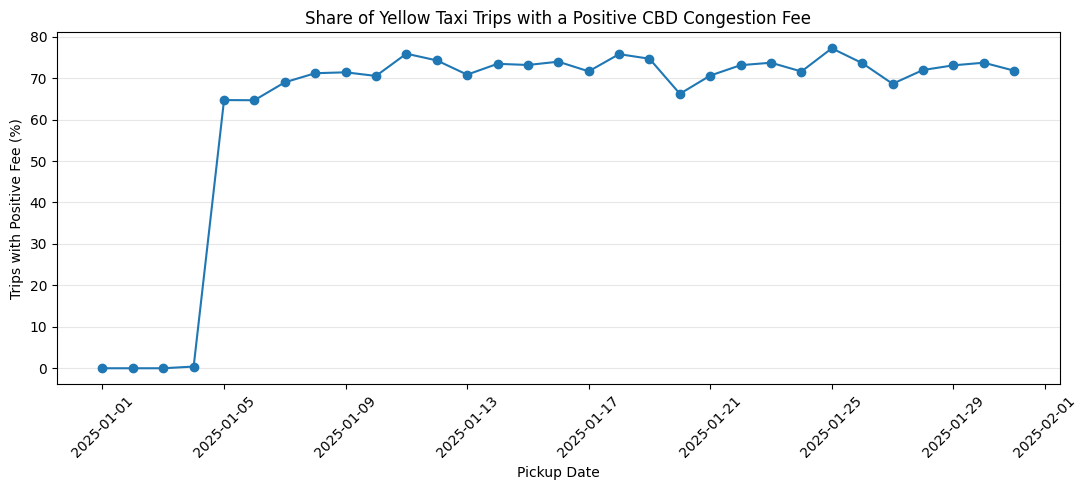

In [26]:
plt.figure(figsize=(11, 5))

plt.plot(
    daily_fee_exposure["pickup_date"],
    daily_fee_exposure["fee_exposure_pct"],
    marker="o",
)

plt.title("Share of Yellow Taxi Trips with a Positive CBD Congestion Fee")
plt.xlabel("Pickup Date")
plt.ylabel("Trips with Positive Fee (%)")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    images_dir / "04_daily_fee_exposure.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [27]:
first_positive_day = daily_fee_exposure.loc[
    daily_fee_exposure["fee_positive_trips"] > 0,
    "pickup_date",
].min()

max_exposure_row = daily_fee_exposure.loc[
    daily_fee_exposure["fee_exposure_pct"].idxmax()
]

print(
    "First date with positive fee records:",
    first_positive_day.date() if pd.notna(first_positive_day) else "None",
)

print(
    f"Highest daily fee exposure: "
    f"{max_exposure_row['fee_exposure_pct']:.1f}% "
    f"on {max_exposure_row['pickup_date'].date()}."
)


First date with positive fee records: 2025-01-04
Highest daily fee exposure: 77.2% on 2025-01-25.


## 3. January 2024 vs January 2025: Citywide Demand

### Business Question

How did overall Yellow Taxi pickup volume change year over year?

### Method

Compare:

- total cleaned January trips
- average trips per day
- average trips per day by weekday

The weekday comparison helps reduce distortion from different weekday/weekend composition across the two calendar years.


In [28]:
citywide_comparison = pd.DataFrame(
    {
        "year": [2024, 2025],
        "total_trips": [
            len(citywide_2024),
            len(citywide_2025),
        ],
        "days": [
            citywide_2024["pickup_date"].nunique(),
            citywide_2025["pickup_date"].nunique(),
        ],
    }
)

citywide_comparison["avg_trips_per_day"] = (
    citywide_comparison["total_trips"] / citywide_comparison["days"]
)

citywide_comparison["yoy_total_change_pct"] = (
    citywide_comparison["total_trips"].pct_change() * 100
)

citywide_comparison


,year,total_trips,days,avg_trips_per_day,yoy_total_change_pct
0,2024,2961964,31,95547.225806,NaN
1,2025,3471950,31,111998.387097,17.217832


In [29]:
def weekday_profile(df, year):
    daily = df.groupby("pickup_date").size().rename("trip_count").reset_index()

    daily["weekday"] = daily["pickup_date"].dt.day_name()
    daily["year"] = year

    return daily


daily_2024 = weekday_profile(citywide_2024, 2024)
daily_2025 = weekday_profile(citywide_2025, 2025)

daily_combined = pd.concat(
    [daily_2024, daily_2025],
    ignore_index=True,
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_yoy = (
    daily_combined.groupby(["year", "weekday"])["trip_count"]
    .mean()
    .unstack("year")
    .reindex(weekday_order)
)

weekday_yoy["change_pct"] = (
    (weekday_yoy[2025] - weekday_yoy[2024]) / weekday_yoy[2024] * 100
)

weekday_yoy


year,2024,2025,change_pct
weekday,,,
Monday,81573.40,90868.25,11.394462
Tuesday,92655.20,113379.00,22.366581
Wednesday,98926.60,115357.20,16.608880
Thursday,107068.75,122728.20,14.625603
Friday,102060.75,117245.00,14.877659
Saturday,105176.50,119008.25,13.150989
Sunday,84741.00,100569.00,18.678090


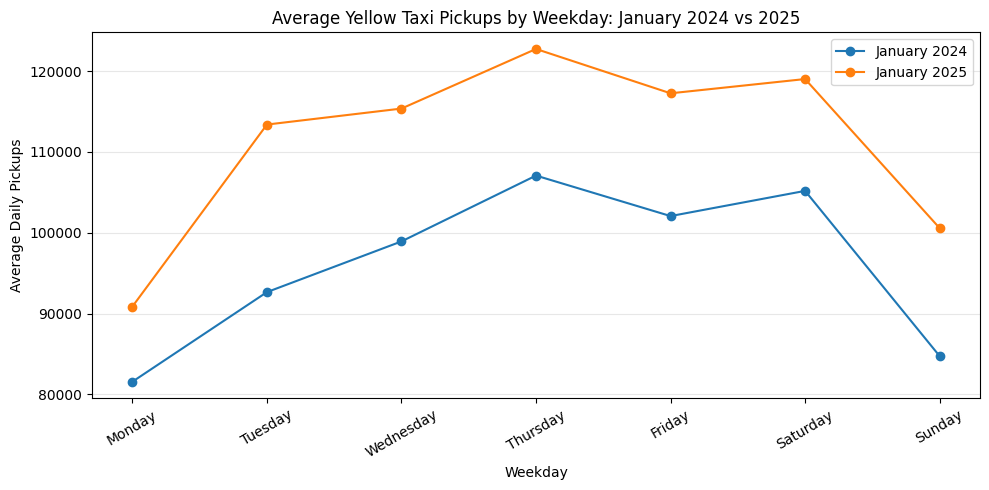

In [30]:
plt.figure(figsize=(10, 5))

plt.plot(
    weekday_order,
    weekday_yoy[2024],
    marker="o",
    label="January 2024",
)

plt.plot(
    weekday_order,
    weekday_yoy[2025],
    marker="o",
    label="January 2025",
)

plt.title("Average Yellow Taxi Pickups by Weekday: January 2024 vs 2025")
plt.xlabel("Weekday")
plt.ylabel("Average Daily Pickups")
plt.xticks(rotation=30)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    images_dir / "04_weekday_yoy_demand.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [31]:
total_change_pct = (len(citywide_2025) - len(citywide_2024)) / len(citywide_2024) * 100

print(
    f"Cleaned January Yellow Taxi demand changed by "
    f"{total_change_pct:+.1f}% from 2024 to 2025."
)


Cleaned January Yellow Taxi demand changed by +17.2% from 2024 to 2025.


## 4. Which Pickup Zones Changed the Most?

### Business Question

Were year-over-year demand changes concentrated in particular pickup zones?

### Method

For each identifiable pickup zone:

1. count January 2024 trips
2. count January 2025 trips
3. compute the absolute and percentage change

To avoid unstable percentage changes from very small zones, the ranking only includes zones with at least **1,000 trips in both years**.

This threshold is used for interpretability, not as a universal data-cleaning rule.


In [32]:
def zone_counts(df, year):
    counts = (
        df.groupby(["PULocationID", "pickup_borough", "pickup_zone"])
        .size()
        .rename(f"trips_{year}")
        .reset_index()
    )

    return counts


zone_counts_2024 = zone_counts(zone_2024, 2024)
zone_counts_2025 = zone_counts(zone_2025, 2025)

zone_yoy = zone_counts_2024.merge(
    zone_counts_2025,
    on=["PULocationID", "pickup_borough", "pickup_zone"],
    how="outer",
)

zone_yoy[["trips_2024", "trips_2025"]] = zone_yoy[["trips_2024", "trips_2025"]].fillna(
    0
)

zone_yoy["trip_change"] = zone_yoy["trips_2025"] - zone_yoy["trips_2024"]

zone_yoy["change_pct"] = np.where(
    zone_yoy["trips_2024"] > 0,
    zone_yoy["trip_change"] / zone_yoy["trips_2024"] * 100,
    np.nan,
)

stable_zone_yoy = zone_yoy.loc[
    (zone_yoy["trips_2024"] >= 1000) & (zone_yoy["trips_2025"] >= 1000)
].copy()

stable_zone_yoy.sort_values(
    "change_pct",
    ascending=False,
).head(10)


,PULocationID,pickup_borough,pickup_zone,trips_2024,trips_2025,trip_change,change_pct
60,61,Brooklyn,Crown Heights North,1045.0,3039.0,1994.0,190.813397
251,255,Brooklyn,Williamsburg (North Side),1109.0,3141.0,2032.0,183.228133
24,25,Brooklyn,Boerum Hill,1050.0,2351.0,1301.0,123.904762
96,97,Brooklyn,Fort Greene,1133.0,2535.0,1402.0,123.742277
32,33,Brooklyn,Brooklyn Heights,1256.0,2668.0,1412.0,112.420382
3,4,Manhattan,Alphabet City,3561.0,7476.0,3915.0,109.941028
64,65,Brooklyn,Downtown Brooklyn/MetroTech,1390.0,2762.0,1372.0,98.705036
41,42,Manhattan,Central Harlem North,3150.0,5980.0,2830.0,89.841270
6,7,Queens,Astoria,1808.0,3184.0,1376.0,76.106195
240,244,Manhattan,Washington Heights South,1891.0,3310.0,1419.0,75.039662


In [33]:
largest_increases = (
    stable_zone_yoy.sort_values(
        "change_pct",
        ascending=False,
    )
    .head(10)
    .copy()
)

largest_decreases = (
    stable_zone_yoy.sort_values(
        "change_pct",
        ascending=True,
    )
    .head(10)
    .copy()
)

largest_increases[
    [
        "pickup_borough",
        "pickup_zone",
        "trips_2024",
        "trips_2025",
        "change_pct",
    ]
]


,pickup_borough,pickup_zone,trips_2024,trips_2025,change_pct
60,Brooklyn,Crown Heights North,1045.0,3039.0,190.813397
251,Brooklyn,Williamsburg (North Side),1109.0,3141.0,183.228133
24,Brooklyn,Boerum Hill,1050.0,2351.0,123.904762
96,Brooklyn,Fort Greene,1133.0,2535.0,123.742277
32,Brooklyn,Brooklyn Heights,1256.0,2668.0,112.420382
3,Manhattan,Alphabet City,3561.0,7476.0,109.941028
64,Brooklyn,Downtown Brooklyn/MetroTech,1390.0,2762.0,98.705036
41,Manhattan,Central Harlem North,3150.0,5980.0,89.841270
6,Queens,Astoria,1808.0,3184.0,76.106195
240,Manhattan,Washington Heights South,1891.0,3310.0,75.039662


In [34]:
largest_decreases[
    [
        "pickup_borough",
        "pickup_zone",
        "trips_2024",
        "trips_2025",
        "change_pct",
    ]
]


,pickup_borough,pickup_zone,trips_2024,trips_2025,change_pct
69,Queens,East Elmhurst,12268.0,9878.0,-19.481578
189,Queens,Queensbridge/Ravenswood,2174.0,1905.0,-12.373505
134,Queens,LaGuardia Airport,89473.0,89544.0,0.079354
42,Manhattan,Central Park,48221.0,48493.0,0.564070
128,Queens,JFK Airport,145052.0,146002.0,0.654938
225,Manhattan,Sutton Place/Turtle Bay North,55177.0,57634.0,4.452942
99,Manhattan,Garment District,48057.0,50701.0,5.501800
138,Manhattan,Lincoln Square East,103973.0,110472.0,6.250661
234,Manhattan,Upper West Side North,64192.0,68554.0,6.795239
139,Manhattan,Lincoln Square West,35544.0,38699.0,8.876322


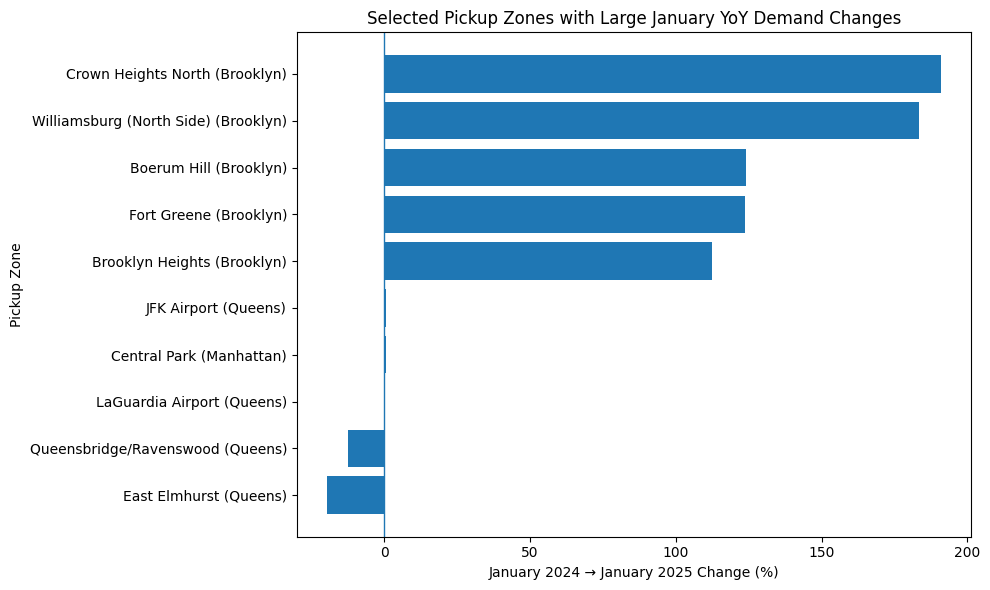

In [35]:
chart_zones = (
    pd.concat(
        [
            largest_decreases.head(5),
            largest_increases.head(5),
        ]
    )
    .drop_duplicates(subset=["PULocationID"])
    .sort_values("change_pct")
    .copy()
)

chart_zones["zone_label"] = (
    chart_zones["pickup_zone"] + " (" + chart_zones["pickup_borough"] + ")"
)

plt.figure(figsize=(10, 6))

plt.barh(
    chart_zones["zone_label"],
    chart_zones["change_pct"],
)

plt.axvline(0, linewidth=1)
plt.title("Selected Pickup Zones with Large January YoY Demand Changes")
plt.xlabel("January 2024 → January 2025 Change (%)")
plt.ylabel("Pickup Zone")
plt.tight_layout()

plt.savefig(
    images_dir / "04_zone_yoy_changes.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


## 5. Congestion-Fee Exposure by Pickup Zone

### Business Question

Were some pickup zones more exposed to trips that received the CBD congestion fee in January 2025?

### Method

For each pickup zone, calculate:

> **fee exposure rate = positive-fee trips / all trips from that pickup zone**

This is an observed exposure measure, not a definition of whether the pickup zone itself is inside the congestion zone.

A trip can originate outside the CBD and later enter it, so this metric should be interpreted as:

> **How often did trips starting in this zone receive a positive CBD congestion fee?**


In [36]:
zone_2025["fee_applied"] = zone_2025["cbd_congestion_fee"].fillna(0) > 0

zone_fee_exposure = (
    zone_2025.groupby(["PULocationID", "pickup_borough", "pickup_zone"])
    .agg(
        total_trips_2025=("fee_applied", "size"),
        fee_positive_trips=("fee_applied", "sum"),
    )
    .reset_index()
)

zone_fee_exposure["fee_exposure_pct"] = (
    zone_fee_exposure["fee_positive_trips"]
    / zone_fee_exposure["total_trips_2025"]
    * 100
)

zone_fee_exposure.sort_values(
    "fee_exposure_pct",
    ascending=False,
).head(15)


,PULocationID,pickup_borough,pickup_zone,total_trips_2025,fee_positive_trips,fee_exposure_pct
194,199,Bronx,Rikers Island,1,1,100.000000
219,224,Manhattan,Stuy Town/Peter Cooper Village,5777,5179,89.648607
229,234,Manhattan,Union Sq,95779,85669,89.444450
3,4,Manhattan,Alphabet City,7476,6670,89.218834
157,162,Manhattan,Midtown East,117838,104786,88.923777
108,113,Manhattan,Greenwich Village North,49393,43811,88.698803
120,125,Manhattan,Hudson Sq,17181,15234,88.667714
244,249,Manhattan,West Village,77299,68494,88.609167
156,161,Manhattan,Midtown Center,169797,150183,88.448559
226,231,Manhattan,TriBeCa/Civic Center,45850,40516,88.366412


## 6. Is Fee Exposure Associated with Zone-Level Demand Change?

### Business Question

Did pickup zones with greater congestion-fee exposure also tend to experience different year-over-year demand changes?

### Method

Merge:

- each zone's January 2024 → January 2025 demand change
- its 2025 fee exposure rate

Then visualize the relationship.

This is **descriptive only**. A visible association does not demonstrate that congestion pricing caused the demand change.


In [37]:
zone_change_exposure = stable_zone_yoy.merge(
    zone_fee_exposure[
        [
            "PULocationID",
            "fee_exposure_pct",
            "total_trips_2025",
        ]
    ],
    on="PULocationID",
    how="left",
)

zone_change_exposure[
    [
        "pickup_borough",
        "pickup_zone",
        "change_pct",
        "fee_exposure_pct",
    ]
].head()


,pickup_borough,pickup_zone,change_pct,fee_exposure_pct
0,Manhattan,Alphabet City,109.941028,89.218834
1,Queens,Astoria,76.106195,21.702261
2,Manhattan,Battery Park City,34.503846,87.635341
3,Manhattan,Bloomingdale,9.227632,18.191365
4,Brooklyn,Boerum Hill,123.904762,23.436835


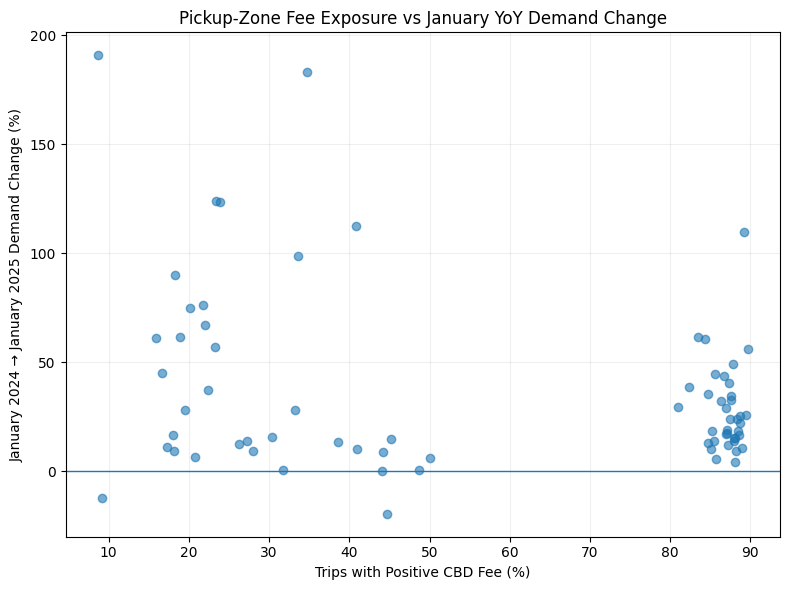

In [38]:
plt.figure(figsize=(8, 6))

plt.scatter(
    zone_change_exposure["fee_exposure_pct"],
    zone_change_exposure["change_pct"],
    alpha=0.6,
)

plt.axhline(0, linewidth=1)
plt.title("Pickup-Zone Fee Exposure vs January YoY Demand Change")
plt.xlabel("Trips with Positive CBD Fee (%)")
plt.ylabel("January 2024 → January 2025 Demand Change (%)")
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    images_dir / "04_fee_exposure_vs_zone_change.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [39]:
association_data = zone_change_exposure[["fee_exposure_pct", "change_pct"]].dropna()

correlation = association_data.corr().iloc[0, 1]

print(
    f"Descriptive correlation between fee exposure and "
    f"zone-level YoY demand change: {correlation:.3f}"
)

print(
    "This correlation is descriptive and should not be interpreted "
    "as a causal effect of congestion pricing."
)


Descriptive correlation between fee exposure and zone-level YoY demand change: -0.272
This correlation is descriptive and should not be interpreted as a causal effect of congestion pricing.


## 7. Executive Summary

The cell below produces a short summary directly from the calculated results.

It intentionally uses descriptive language and avoids causal claims.


In [40]:
largest_increase = largest_increases.iloc[0]
largest_decrease = largest_decreases.iloc[0]

overall_fee_exposure = citywide_2025["fee_applied"].mean() * 100

print("NYC Yellow Taxi Congestion Pricing Analysis")
print("-" * 52)

print(
    f"1. January Yellow Taxi pickup volume changed by "
    f"{total_change_pct:+.1f}% from 2024 to 2025."
)

print(
    f"2. In January 2025, {overall_fee_exposure:.1f}% of cleaned "
    f"Yellow Taxi trips recorded a positive CBD congestion fee."
)

print(
    f"3. Largest increase among stable-volume zones: "
    f"{largest_increase['pickup_zone']} "
    f"({largest_increase['change_pct']:+.1f}%)."
)

print(
    f"4. Largest decrease among stable-volume zones: "
    f"{largest_decrease['pickup_zone']} "
    f"({largest_decrease['change_pct']:+.1f}%)."
)

print(
    f"5. Fee exposure and zone-level demand change have a "
    f"descriptive correlation of {correlation:.3f}."
)


NYC Yellow Taxi Congestion Pricing Analysis
----------------------------------------------------
1. January Yellow Taxi pickup volume changed by +17.2% from 2024 to 2025.
2. In January 2025, 64.7% of cleaned Yellow Taxi trips recorded a positive CBD congestion fee.
3. Largest increase among stable-volume zones: Crown Heights North (+190.8%).
4. Largest decrease among stable-volume zones: East Elmhurst (-19.5%).
5. Fee exposure and zone-level demand change have a descriptive correlation of -0.272.


## 8. Limitations and Interpretation

### Important limitations

- The comparison covers **January 2024 vs January 2025**, not the full years.
- Weather, holidays, economic conditions, transit changes, taxi supply, and other factors may also affect demand.
- January 2025 includes both pre- and post-congestion-pricing days.
- A positive `cbd_congestion_fee` is an observed trip-level fee signal, not a direct classification of the pickup zone itself.
- Negative fee values may represent reversals or adjustments and are not counted as positive fee exposure.
- Zone-level percentage changes can be unstable for low-volume locations; therefore the primary ranking uses a minimum-volume threshold.
- Correlation between fee exposure and demand change does **not** establish causality.

### Next Step

A later advanced extension could use:

- longer pre/post periods
- explicit congestion-zone treatment definitions
- weather and calendar controls
- formal Difference-in-Differences with a defensible comparison group

Keep those methods outside Version 1 until the descriptive analysis is fully understood.
